# 🎓 SVM in University Life
## Project: Student Academic Outcome Classification

---

### 🎯 Project Overview

Universities want to identify **at-risk students early** so that support services (tutoring, counselling, bursaries) can be targeted effectively. This project uses **Support Vector Machines (SVM)** to classify students into outcome categories based on academic and lifestyle features.

**Classification targets:**
| Class | Label | Description |
|-------|-------|-------------|
| 0 | Pass | Passes the year with ≥40% overall |
| 1 | At-Risk | Borderline — likely to need resits |
| 2 | Dropout Risk | High probability of withdrawing |

**Features used:**
- Assignment submission rate (%)
- Lecture attendance rate (%)
- Average assessment grade (%)
- Study hours per week
- Part-time work hours per week
- Self-reported stress level (1–10)
- Library/VLE engagement score (0–100)

---

> **Ethical note:** Predictive models in education carry responsibility. This project includes a discussion of fairness, bias, and appropriate use.

### 📚 Learning Objectives
1. Apply SVM to a relatable classification problem
2. Compare multiple kernels and C values
3. Understand precision vs. recall trade-offs in a human-centred context
4. Critically evaluate SVM pros & cons for educational data

## 🧮 Section 1: SVM Theory Recap

### The Soft-Margin SVM (C-SVM)

Real data is rarely perfectly separable. The **soft-margin** SVM introduces **slack variables** $\xi_i \geq 0$:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i \quad \text{s.t. } y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 - \xi_i, \; \xi_i \geq 0$$

**The C parameter controls the bias-variance trade-off:**

| C Value | Effect | Risk |
|---------|--------|------|
| Small C | Wide margin, more misclassifications allowed | Underfitting (high bias) |
| Large C | Narrow margin, few misclassifications | Overfitting (high variance) |

### Intuition for University Data
Student data is **noisy and overlapping**: a student with 70% attendance might pass *or* be at risk depending on other factors. The soft margin lets SVM handle this naturally — some "misclassifications" in the margin are acceptable for a better overall boundary.

### Multi-class: One-vs-Rest (OvR)
For 3 classes: train 3 binary classifiers (Pass vs rest, At-Risk vs rest, Dropout vs rest). Assign to class with highest decision function score.

In [1]:
# ============================================================
# CELL 1: Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold,
                                     learning_curve)
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

np.random.seed(2024)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# ============================================================
# CELL 2: Generate Synthetic Student Dataset
# ============================================================

def generate_student_data(n=900):
    """
    Simulate student data with realistic correlations:
    - High attendance + high submission → likely Pass
    - High work hours + high stress → more at-risk/dropout
    - Overlapping distributions (realistic!)
    """
    n_pass    = n // 2
    n_atrisk  = n // 3
    n_dropout = n - n_pass - n_atrisk

    def make_students(n_s, temp_K, pressure_K, conc_K, flow_K, rate_K, stress_K, engage_K):
        return np.column_stack([
            np.clip(np.random.normal(temp_K,    10, n_s), 0, 100),   # Submission rate %
            np.clip(np.random.normal(pressure_K, 12, n_s), 0, 100),  # Attendance %
            np.clip(np.random.normal(conc_K,     10, n_s), 0, 100),  # Avg grade %
            np.clip(np.random.normal(flow_K,      4, n_s), 0, 60),   # Study hrs/week
            np.clip(np.random.normal(rate_K,      4, n_s), 0, 40),   # Work hrs/week
            np.clip(np.random.normal(stress_K,    1.5, n_s), 1, 10), # Stress 1-10
            np.clip(np.random.normal(engage_K,   15, n_s), 0, 100),  # VLE engagement
        ])

    # Class 0: Passing students
    X0 = make_students(n_pass,   90, 85, 65, 20, 8,  3, 75)  # high sub, attend, grade
    # Class 1: At-risk students
    X1 = make_students(n_atrisk, 72, 68, 48, 15, 16, 6, 50)  # moderate, more work
    # Class 2: Dropout risk
    X2 = make_students(n_dropout,50, 50, 35, 9,  22, 8, 25)  # low engagement, high work

    X = np.vstack([X0, X1, X2])
    y = np.concatenate([np.zeros(n_pass), np.ones(n_atrisk), np.full(n_dropout, 2)]).astype(int)
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]


X, y = generate_student_data(900)

feature_names = [
    'Submission Rate (%)', 'Attendance (%)', 'Avg Grade (%)',
    'Study Hrs/Week', 'Work Hrs/Week', 'Stress Level (1–10)', 'VLE Engagement'
]
class_names  = ['Pass', 'At-Risk', 'Dropout Risk']
class_colors = ['#27ae60', '#f39c12', '#e74c3c']

df = pd.DataFrame(X, columns=feature_names)
df['Outcome_Code']  = y
df['Outcome_Label'] = df['Outcome_Code'].map(dict(enumerate(class_names)))

print('🎓 Student Dataset Summary')
print('='*55)
print(df['Outcome_Label'].value_counts())
print()
print(df.groupby('Outcome_Label')[feature_names].mean().round(1).T)

🎓 Student Dataset Summary
Outcome_Label
Pass            450
At-Risk         300
Dropout Risk    150
Name: count, dtype: int64

Outcome_Label        At-Risk  Dropout Risk  Pass
Submission Rate (%)     71.7          50.7  88.9
Attendance (%)          68.1          50.9  84.9
Avg Grade (%)           48.3          34.8  65.0
Study Hrs/Week          14.6           9.1  20.0
Work Hrs/Week           16.2          22.3   7.9
Stress Level (1–10)      6.1           7.8   3.2
VLE Engagement          50.6          27.7  75.1


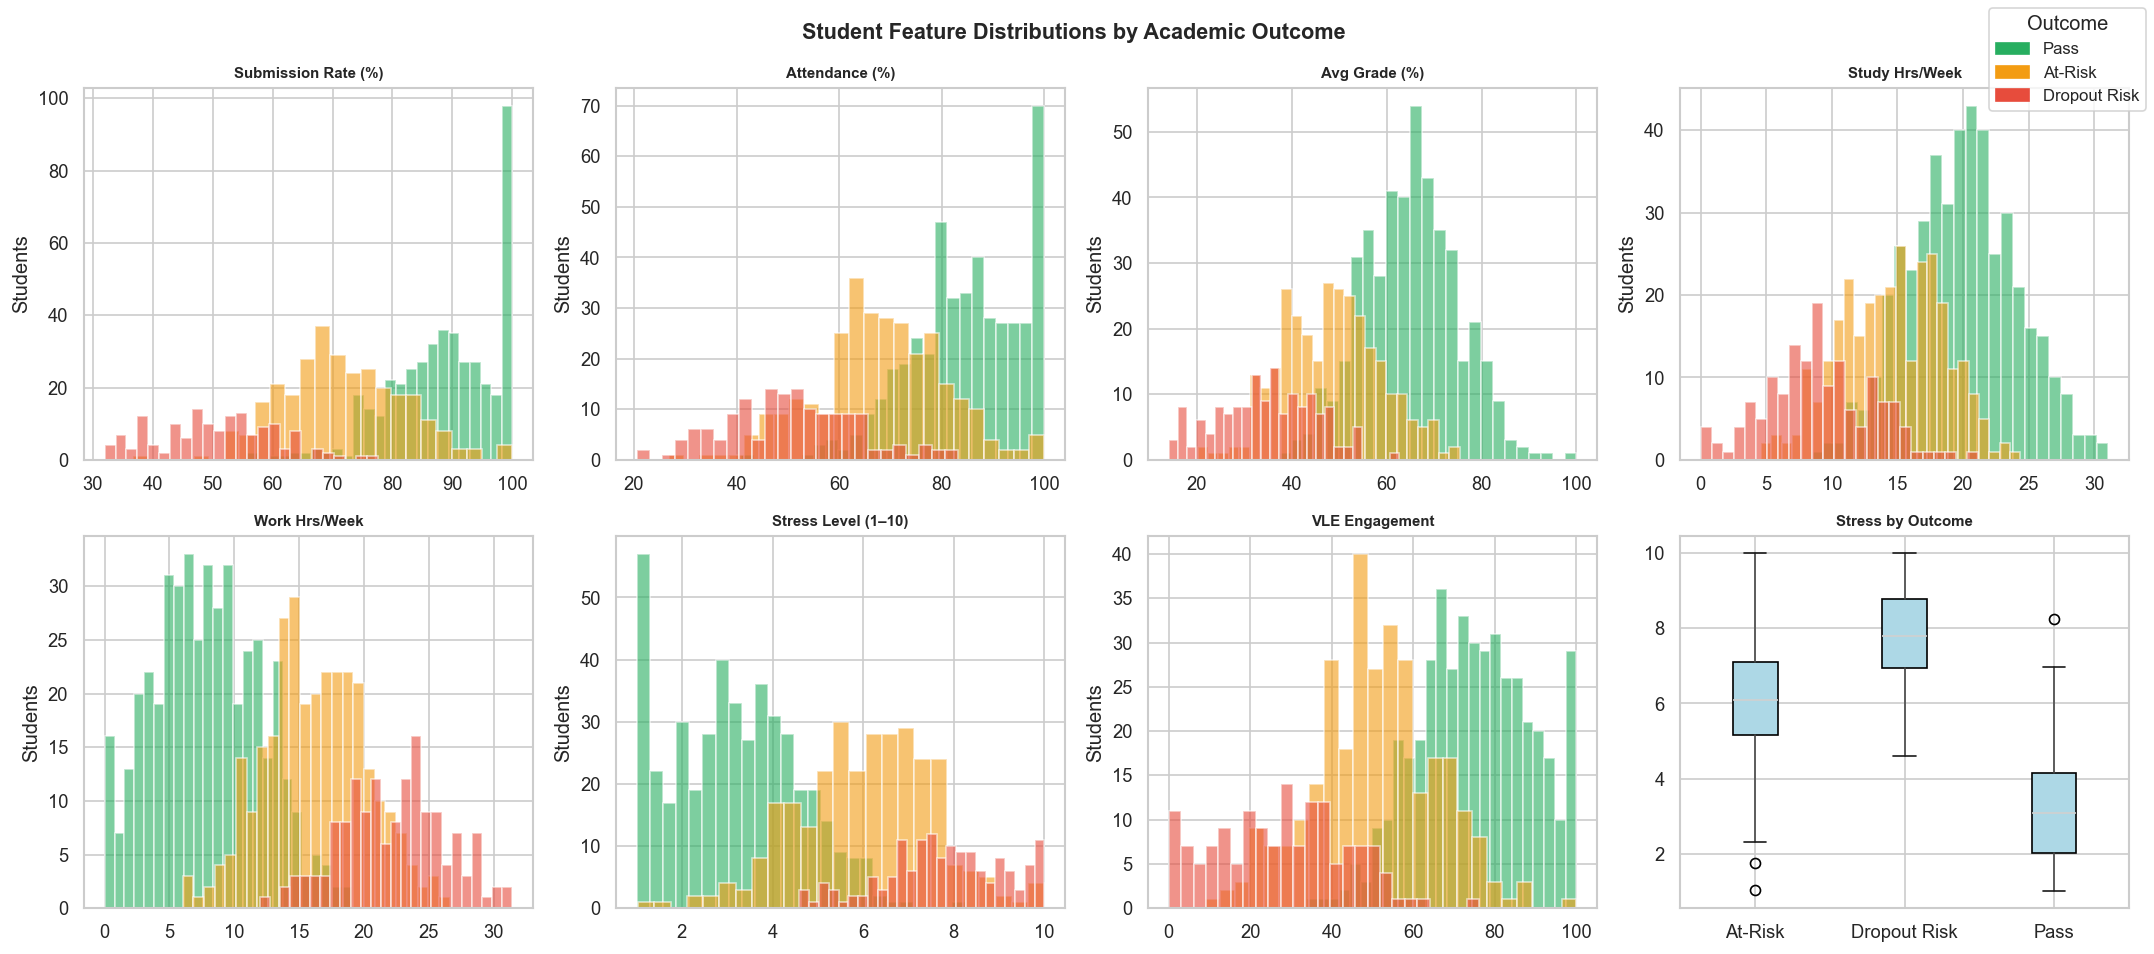

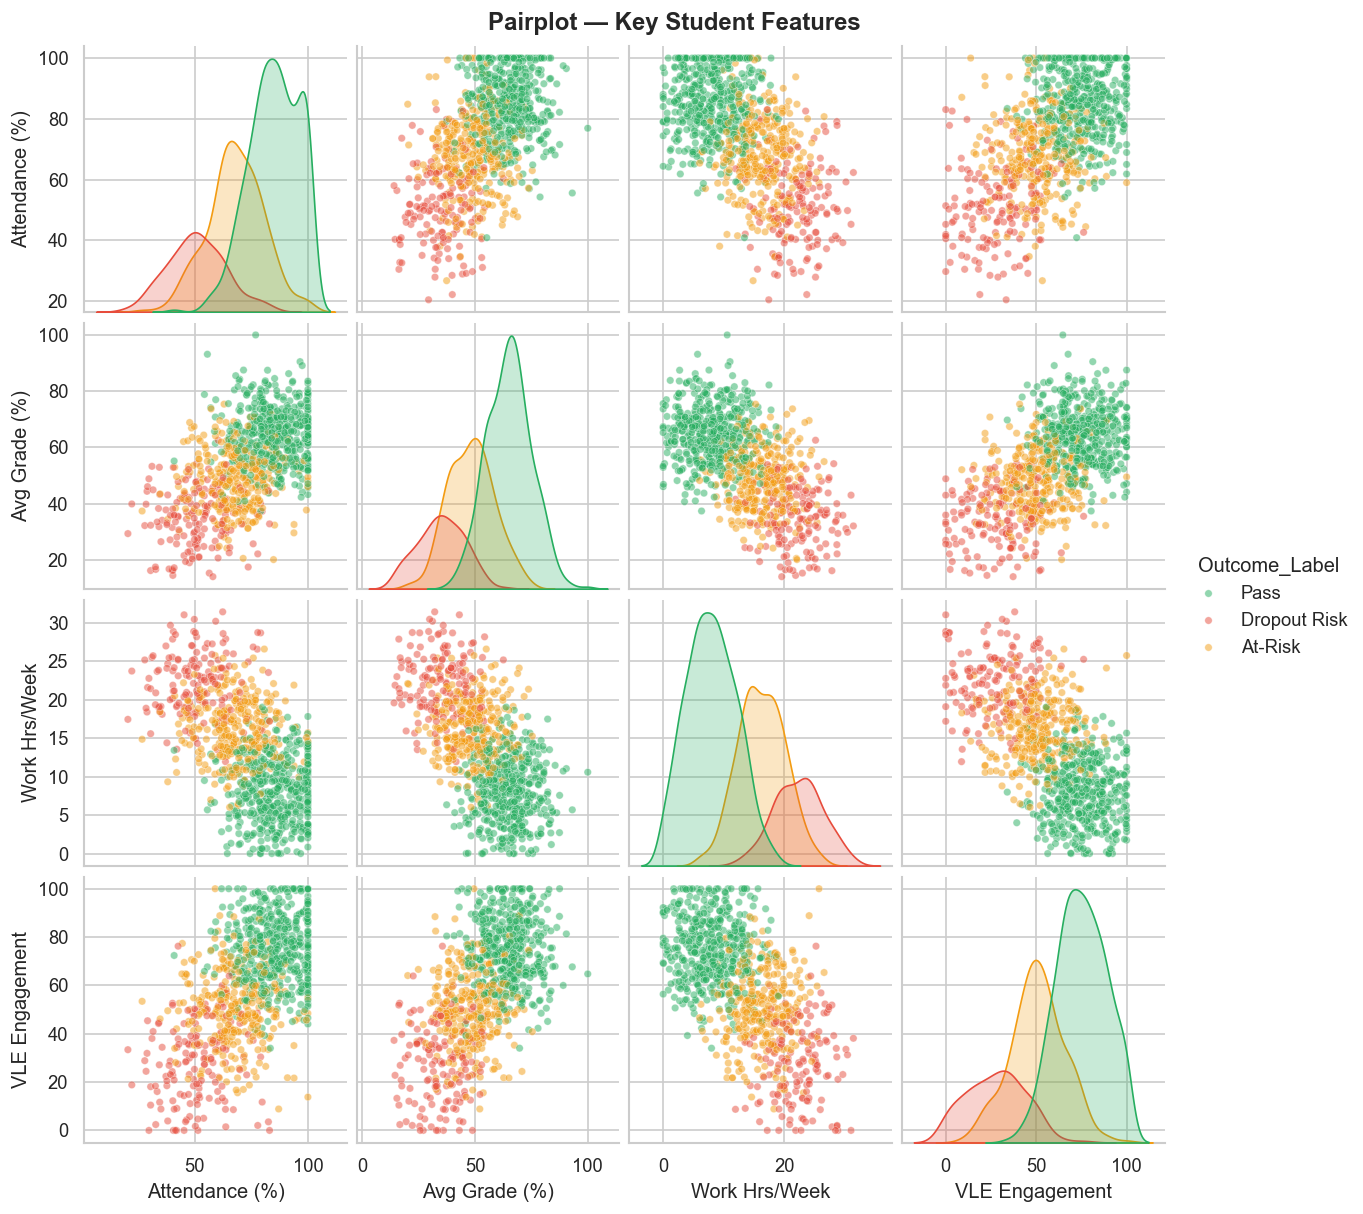

In [3]:
# ============================================================
# CELL 3: EDA — Visualising the Student Data
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes_flat = axes.flatten()

for i, feat in enumerate(feature_names):
    ax = axes_flat[i]
    for cls_idx, (cls_name, color) in enumerate(zip(class_names, class_colors)):
        data_cls = df[df['Outcome_Code'] == cls_idx][feat]
        ax.hist(data_cls, bins=25, alpha=0.6, color=color, label=cls_name, edgecolor='white')
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_ylabel('Students')

# Last panel: boxplot for Stress Level
ax = axes_flat[7]
df.boxplot(column='Stress Level (1–10)', by='Outcome_Label', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('Stress by Outcome', fontweight='bold', fontsize=9)
ax.set_xlabel('')
plt.suptitle('', y=-0.01)

handles = [mpatches.Patch(color=c, label=n) for c, n in zip(class_colors, class_names)]
fig.legend(handles=handles, loc='upper right', fontsize=10, title='Outcome')
plt.suptitle(' Student Feature Distributions by Academic Outcome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot of key features
key_feats = ['Attendance (%)', 'Avg Grade (%)', 'Work Hrs/Week', 'VLE Engagement']
pair_df = df[key_feats + ['Outcome_Label']].copy()
g = sns.pairplot(pair_df, hue='Outcome_Label',
                 palette=dict(zip(class_names, class_colors)),
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Key Student Features', y=1.01, fontweight='bold')
plt.show()

In [4]:
# ============================================================
# CELL 4: Preprocessing
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('📐 Data Split')
print(f'Training  : {len(X_train)} students')
print(f'Test set  : {len(X_test)} students')
print()
print('💡 Why StandardScaler?')
print('   Submission Rate is 0–100, Study Hours is 0–60, Stress is 1–10.')
print('   Without scaling, Study Hours range would dominate SVM distances.')
print()

# Show before/after for one feature
print('Feature: Work Hrs/Week')
print(f'  Before: mean={X_train[:,4].mean():.1f}, std={X_train[:,4].std():.1f}')
print(f'  After:  mean={X_train_sc[:,4].mean():.4f}, std={X_train_sc[:,4].std():.4f}')

📐 Data Split
Training  : 675 students
Test set  : 225 students

💡 Why StandardScaler?
   Submission Rate is 0–100, Study Hours is 0–60, Stress is 1–10.
   Without scaling, Study Hours range would dominate SVM distances.

Feature: Work Hrs/Week
  Before: mean=13.1, std=6.8
  After:  mean=0.0000, std=1.0000


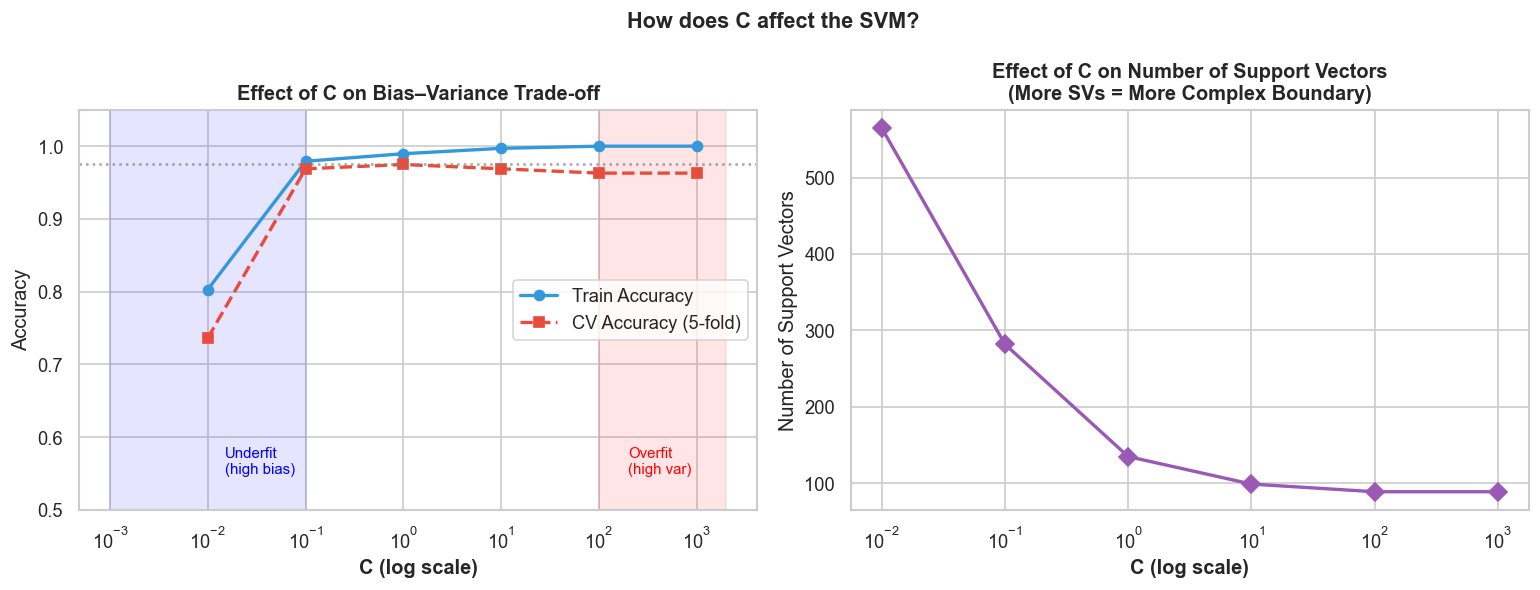

💡 Key insight:
   Small C → wide margin, many misclassifications allowed, more SVs
   Large C → narrow margin, fewer misclassifications, fewer SVs
   Best C  → where CV accuracy peaks!
   → Optimal C ≈ 1


In [5]:
# ============================================================
# CELL 5: Effect of C — Understanding Regularisation
# ============================================================
# This cell demonstrates HOW C affects the model — great for learning!

C_values = [0.01, 0.1, 1, 10, 100, 1000]
train_accs, cv_accs, n_svs = [], [], []

for C in C_values:
    model = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    cv    = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    model.fit(X_train_sc, y_train)
    train_accs.append(model.score(X_train_sc, y_train))
    cv_accs.append(cv.mean())
    n_svs.append(sum(model.n_support_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogx(C_values, train_accs, 'o-', label='Train Accuracy', color='#3498db', lw=2)
ax.semilogx(C_values, cv_accs, 's--', label='CV Accuracy (5-fold)', color='#e74c3c', lw=2)
ax.axhline(max(cv_accs), color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('C (log scale)', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of C on Bias–Variance Trade-off', fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)

# Annotate regions
ax.axvspan(0.001, 0.1, alpha=0.1, color='blue', label='Underfitting')
ax.axvspan(100, 2000, alpha=0.1, color='red', label='Overfitting')
ax.text(0.015, 0.55, 'Underfit\n(high bias)', color='blue', fontsize=9)
ax.text(200, 0.55, 'Overfit\n(high var)', color='red', fontsize=9)

ax = axes[1]
ax.semilogx(C_values, n_svs, 'D-', color='#9b59b6', lw=2, ms=8)
ax.set_xlabel('C (log scale)', fontweight='bold')
ax.set_ylabel('Number of Support Vectors')
ax.set_title('Effect of C on Number of Support Vectors\n(More SVs = More Complex Boundary)', fontweight='bold')

plt.suptitle(' How does C affect the SVM?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Key insight:')
print('   Small C → wide margin, many misclassifications allowed, more SVs')
print('   Large C → narrow margin, fewer misclassifications, fewer SVs')
print('   Best C  → where CV accuracy peaks!')
best_idx = cv_accs.index(max(cv_accs))
print(f'   → Optimal C ≈ {C_values[best_idx]}')

In [6]:
# ============================================================
# CELL 6: Kernel Comparison
# ============================================================

kernel_configs = {
    'Linear'          : SVC(kernel='linear', C=1, random_state=42),
    'RBF (C=1)'       : SVC(kernel='rbf', C=1,   gamma='scale', random_state=42),
    'RBF (C=10)'      : SVC(kernel='rbf', C=10,  gamma='scale', random_state=42),
    'Polynomial d=2'  : SVC(kernel='poly', C=1,  degree=2, random_state=42),
    'Polynomial d=3'  : SVC(kernel='poly', C=1,  degree=3, random_state=42),
}

print('🔬 Kernel Comparison\n' + '='*55)
print(f'{"Model":<22} {"CV Acc":>9} {"Test Acc":>10} {"# SVs":>7}')
print('-'*52)

kernel_results = {}
for name, model in kernel_configs.items():
    cv = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    model.fit(X_train_sc, y_train)
    test_a = model.score(X_test_sc, y_test)
    kernel_results[name] = {'cv': cv.mean(), 'test': test_a, 'svs': sum(model.n_support_)}
    print(f'{name:<22} {cv.mean():>9.4f} {test_a:>10.4f} {sum(model.n_support_):>7}')

best_k = max(kernel_results, key=lambda k: kernel_results[k]['cv'])
print(f'\n🏆 Best: {best_k}')

🔬 Kernel Comparison
Model                     CV Acc   Test Acc   # SVs
----------------------------------------------------
Linear                    0.9763     0.9911      59
RBF (C=1)                 0.9748     0.9867     135
RBF (C=10)                0.9689     0.9867      99
Polynomial d=2            0.7363     0.7733     441
Polynomial d=3            0.9615     0.9778     179

🏆 Best: Linear


Best params   : {'C': 10, 'gamma': 0.01}
Best CV acc   : 0.9822


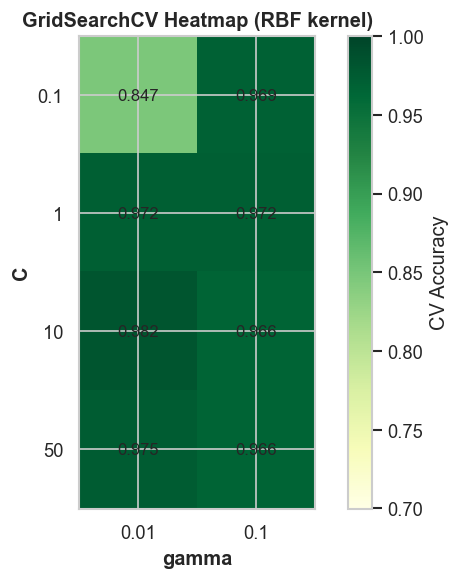

In [7]:
# ============================================================
# CELL 7: Hyperparameter Tuning
# ============================================================

param_grid = {
    'C'    : [0.1, 1, 10, 50],
    'gamma': ['scale', 0.01, 0.1]
}

grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train_sc, y_train)

print(f'Best params   : {grid.best_params_}')
print(f'Best CV acc   : {grid.best_score_:.4f}')

# Heatmap (just numeric gammas)
numeric_gammas = [0.01, 0.1]
C_vals = [0.1, 1, 10, 50]
score_matrix = np.zeros((len(C_vals), len(numeric_gammas)))

results_df = pd.DataFrame(grid.cv_results_)
for i, C in enumerate(C_vals):
    for j, g in enumerate(numeric_gammas):
        row = results_df[(results_df['param_C'] == C) & (results_df['param_gamma'] == g)]
        if len(row):
            score_matrix[i, j] = row['mean_test_score'].values[0]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(score_matrix, cmap='YlGn', vmin=0.7, vmax=1.0)
plt.colorbar(im, ax=ax, label='CV Accuracy')
ax.set_xticks(range(len(numeric_gammas))); ax.set_xticklabels(numeric_gammas)
ax.set_yticks(range(len(C_vals)));         ax.set_yticklabels(C_vals)
ax.set_xlabel('gamma', fontweight='bold')
ax.set_ylabel('C', fontweight='bold')
ax.set_title('GridSearchCV Heatmap (RBF kernel)', fontweight='bold')
for i in range(len(C_vals)):
    for j in range(len(numeric_gammas)):
        ax.text(j, i, f'{score_matrix[i,j]:.3f}', ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()

🎓 Final Model Results
Test Accuracy: 0.9867 (98.7%)
Best params  : {'C': 10, 'gamma': 0.01}

              precision    recall  f1-score   support

        Pass       0.98      1.00      0.99       113
     At-Risk       0.99      0.97      0.98        75
Dropout Risk       1.00      0.97      0.99        37

    accuracy                           0.99       225
   macro avg       0.99      0.98      0.99       225
weighted avg       0.99      0.99      0.99       225



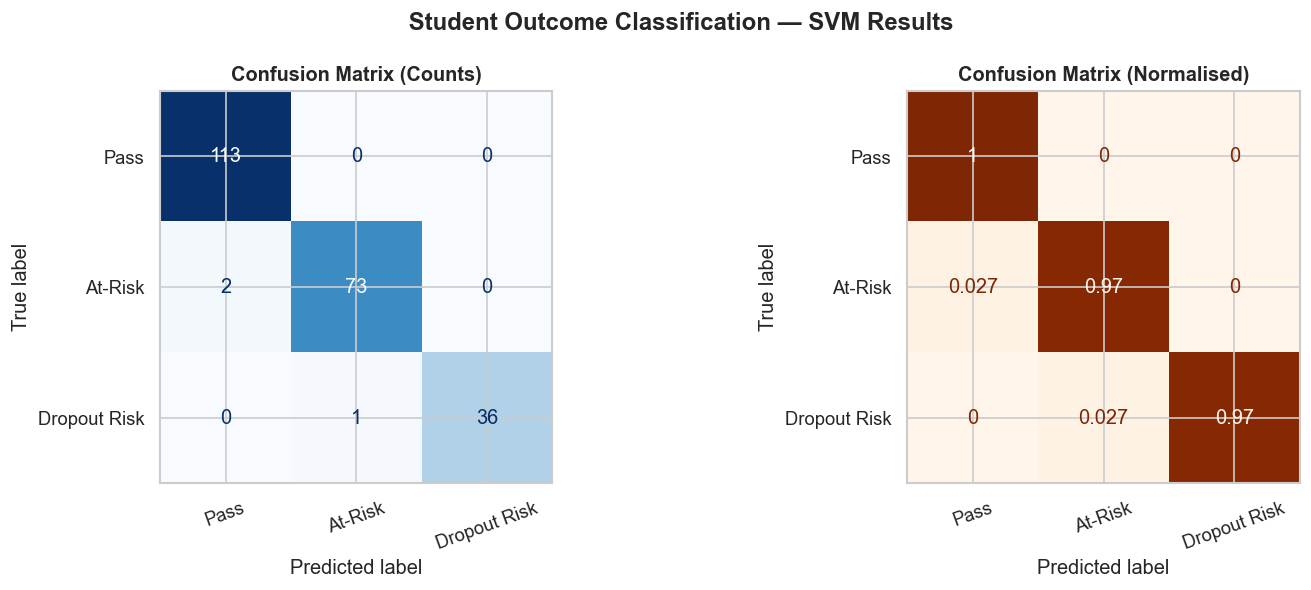

In [8]:
# ============================================================
# CELL 8: Final Model + Confusion Matrix
# ============================================================

svm_final = grid.best_estimator_
y_pred = svm_final.predict(X_test_sc)
test_acc = svm_final.score(X_test_sc, y_test)

print('🎓 Final Model Results')
print('='*55)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'Best params  : {grid.best_params_}')
print()
print(classification_report(y_test, y_pred, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle(' Student Outcome Classification — SVM Results', fontweight='bold')
plt.tight_layout()
plt.show()

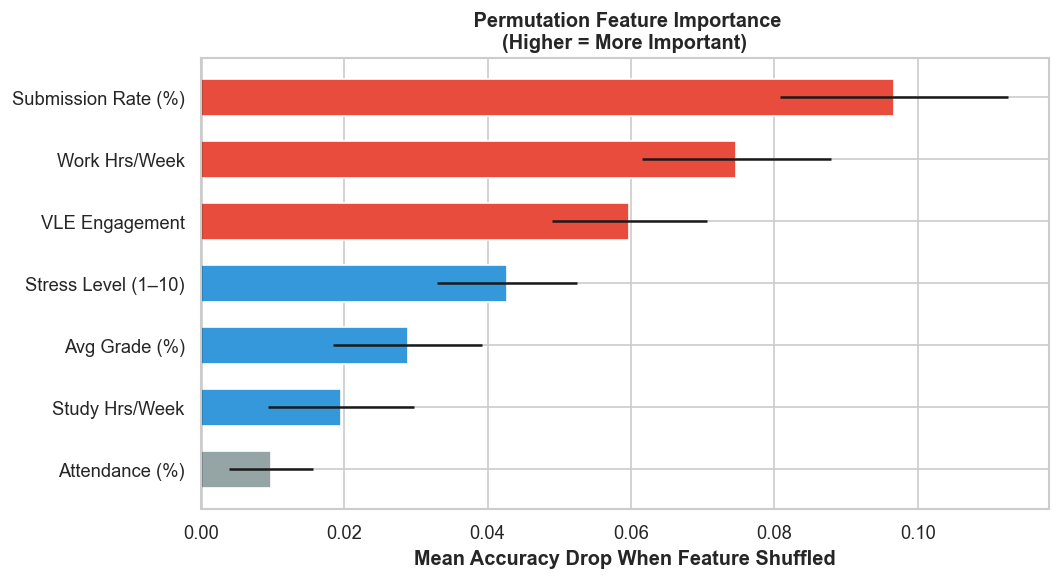

💡 Interpretation:
   Features with high permutation importance drive the classification.
   This helps the university know WHICH metrics to focus on.

   #1: Submission Rate (%) (drop = 0.0967)
   #2: Work Hrs/Week (drop = 0.0747)
   #3: VLE Engagement (drop = 0.0598)


In [9]:
# ============================================================
# CELL 9: Feature Importance via Permutation
# ============================================================
# SVM has no built-in feature importance — we use permutation importance:
# "How much does accuracy drop when we randomly shuffle feature X?"

perm_imp = permutation_importance(
    svm_final, X_test_sc, y_test,
    n_repeats=20, random_state=42, scoring='accuracy'
)

sorted_idx = perm_imp.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0.05 else '#3498db' if v > 0.01 else '#95a5a6'
          for v in perm_imp.importances_mean[sorted_idx]]
ax.barh(
    [feature_names[i] for i in sorted_idx],
    perm_imp.importances_mean[sorted_idx],
    xerr=perm_imp.importances_std[sorted_idx],
    color=colors, edgecolor='white', height=0.6
)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean Accuracy Drop When Feature Shuffled', fontweight='bold')
ax.set_title(' Permutation Feature Importance\n(Higher = More Important)', fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Interpretation:')
print('   Features with high permutation importance drive the classification.')
print('   This helps the university know WHICH metrics to focus on.')
print()
top = np.argsort(perm_imp.importances_mean)[::-1][:3]
for rank, idx in enumerate(top, 1):
    print(f'   #{rank}: {feature_names[idx]} (drop = {perm_imp.importances_mean[idx]:.4f})')

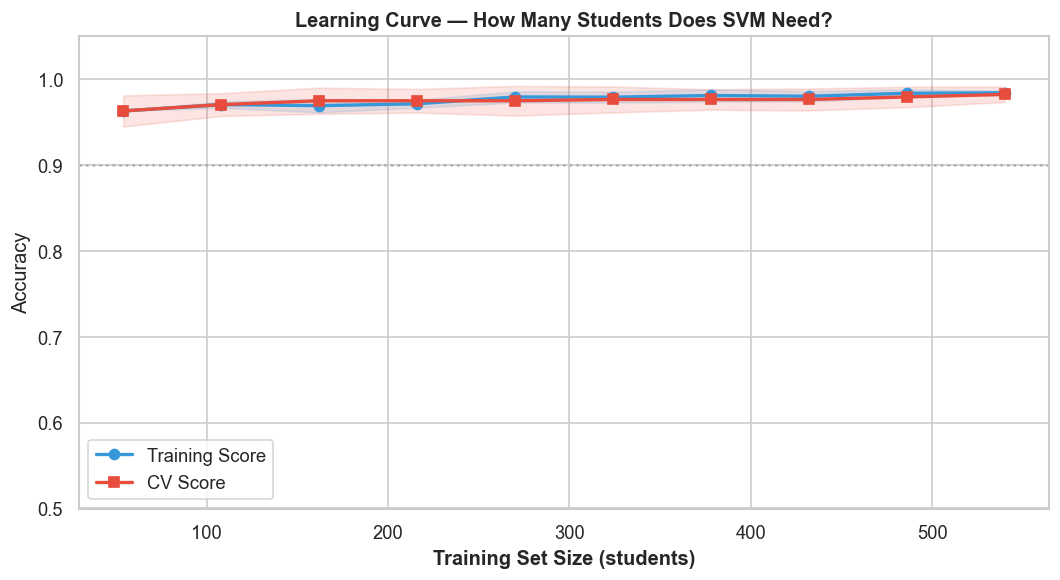

💡 Learning curve insights:
   - If train >> val accuracy: overfitting (need more data or higher C)
   - If both plateau low: underfitting (try different kernel/features)
   - Plateau where curves meet: ideal training size found


In [10]:
# ============================================================
# CELL 10: Learning Curve — How Much Data Do We Need?
# ============================================================
# This is a CRITICAL question for universities with small cohorts!

train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'],
        random_state=42),
    X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='#3498db')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1), alpha=0.15, color='#e74c3c')
ax.plot(train_sizes, train_scores.mean(1), 'o-', label='Training Score', color='#3498db', lw=2)
ax.plot(train_sizes, val_scores.mean(1), 's-', label='CV Score', color='#e74c3c', lw=2)
ax.set_xlabel('Training Set Size (students)', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — How Many Students Does SVM Need?', fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='90% target')
plt.tight_layout()
plt.show()

print('💡 Learning curve insights:')
print('   - If train >> val accuracy: overfitting (need more data or higher C)')
print('   - If both plateau low: underfitting (try different kernel/features)')
print('   - Plateau where curves meet: ideal training size found')

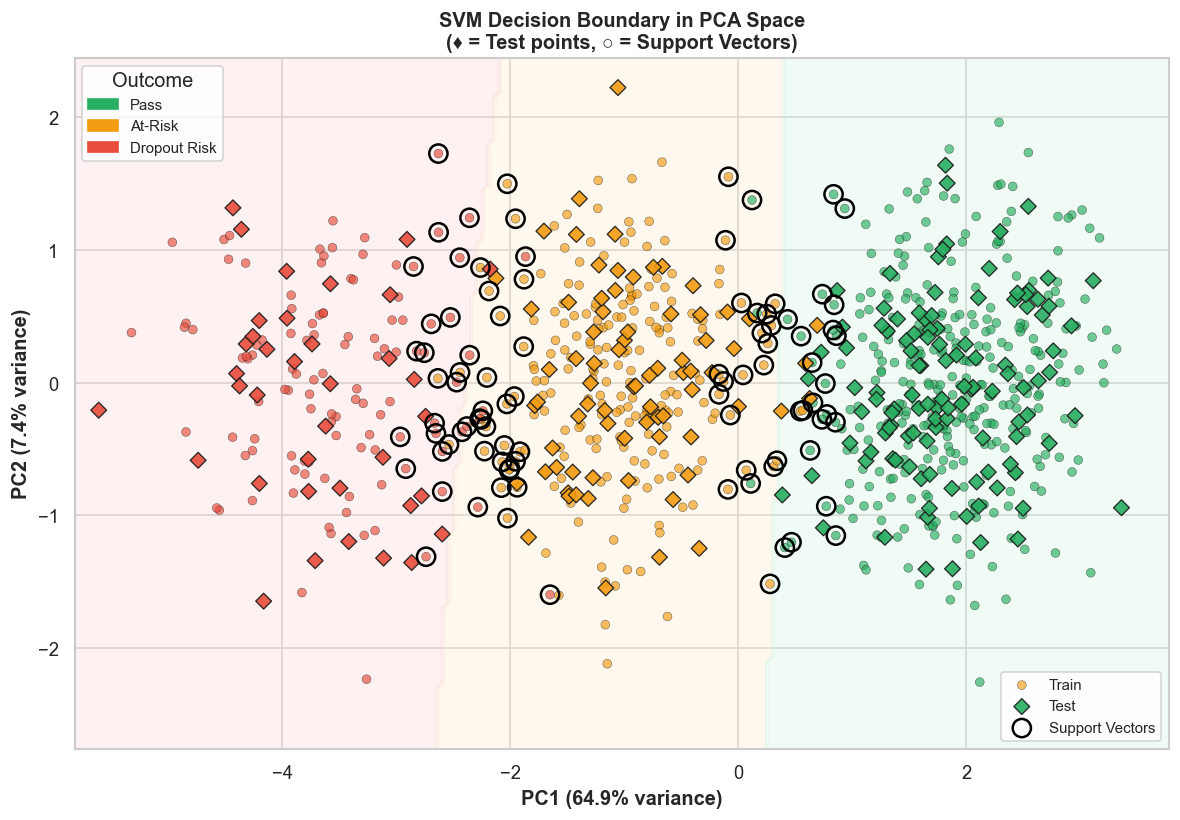

In [11]:
# ============================================================
# CELL 11: Decision Boundary Visualisation (2D PCA)
# ============================================================

pca = PCA(n_components=2)
X_tr_2d = pca.fit_transform(X_train_sc)
X_te_2d = pca.transform(X_test_sc)

svm_2d = SVC(kernel='rbf', C=grid.best_params_['C'],
             gamma=grid.best_params_['gamma'], random_state=42)
svm_2d.fit(X_tr_2d, y_train)

h = 0.05
x1_min, x1_max = X_tr_2d[:,0].min()-0.5, X_tr_2d[:,0].max()+0.5
x2_min, x2_max = X_tr_2d[:,1].min()-0.5, X_tr_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
cmap_bg  = ListedColormap(['#d5f5e3','#fdebd0','#fadbd8'])
cmap_pts = ListedColormap(class_colors)

ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
ax.scatter(X_tr_2d[:,0], X_tr_2d[:,1], c=y_train, cmap=cmap_pts,
           edgecolors='k', linewidths=0.3, s=28, alpha=0.65, label='Train')
ax.scatter(X_te_2d[:,0], X_te_2d[:,1], c=y_test, cmap=cmap_pts,
           marker='D', edgecolors='k', linewidths=0.8, s=45, alpha=0.9, label='Test')
svs = svm_2d.support_vectors_
ax.scatter(svs[:,0], svs[:,1], s=120, facecolors='none',
           edgecolors='black', linewidths=1.5, label='Support Vectors')

patches = [mpatches.Patch(color=c, label=n) for c, n in zip(class_colors, class_names)]
legend1 = ax.legend(handles=patches, loc='upper left', title='Outcome', fontsize=9)
ax.add_artist(legend1)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
ax.set_title('SVM Decision Boundary in PCA Space\n(♦ = Test points, ○ = Support Vectors)', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# CELL 12: Predicting New Students
# ============================================================

def predict_student(submission_pct, attendance_pct, avg_grade, study_hrs,
                    work_hrs, stress, vle_engagement, verbose=True):
    """Predict academic outcome for a student profile."""
    reading = np.array([[submission_pct, attendance_pct, avg_grade,
                         study_hrs, work_hrs, stress, vle_engagement]])
    reading_sc = scaler.transform(reading)
    pred = svm_final.predict(reading_sc)[0]
    label = class_names[pred]
    icon  = ['🟢', '🟡', '🔴'][pred]
    if verbose:
        print(f'  Profile: Submission={submission_pct}%, Attendance={attendance_pct}%, '
              f'Grade={avg_grade}%, Study={study_hrs}h, Work={work_hrs}h, '
              f'Stress={stress}, VLE={vle_engagement}')
        print(f'  → Predicted Outcome: {icon} {label}\n')
    return pred

print('🏫 Student Risk Assessment Predictions\n' + '='*60)

print('Student A — High performer')
predict_student(95, 90, 72, 22, 6, 2, 80)

print('Student B — Struggling but engaged')
predict_student(75, 70, 50, 14, 18, 6, 52)

print('Student C — High dropout risk')
predict_student(40, 45, 32, 7, 25, 9, 20)

print('Student D — Borderline case')
predict_student(68, 65, 48, 16, 12, 5, 48)

🏫 Student Risk Assessment Predictions
Student A — High performer
  Profile: Submission=95%, Attendance=90%, Grade=72%, Study=22h, Work=6h, Stress=2, VLE=80
  → Predicted Outcome: 🟢 Pass

Student B — Struggling but engaged
  Profile: Submission=75%, Attendance=70%, Grade=50%, Study=14h, Work=18h, Stress=6, VLE=52
  → Predicted Outcome: 🟡 At-Risk

Student C — High dropout risk
  Profile: Submission=40%, Attendance=45%, Grade=32%, Study=7h, Work=25h, Stress=9, VLE=20
  → Predicted Outcome: 🔴 Dropout Risk

Student D — Borderline case
  Profile: Submission=68%, Attendance=65%, Grade=48%, Study=16h, Work=12h, Stress=5, VLE=48
  → Predicted Outcome: 🟡 At-Risk



1

## 📊 Pros & Cons of SVM for University Student Data

---

### ✅ Advantages

| Advantage | Why it Matters for Student Data |
|-----------|--------------------------------|
| **Works well with small datasets** | A single university cohort may have 200–2000 students — not millions |
| **Effective in high-dimensional spaces** | Many features (grades per module, engagement per week) without curse of dimensionality |
| **Robust to overfitting** (with correct C) | Regularisation prevents memorising individual student quirks |
| **Handles overlapping classes well** | At-risk vs passing students genuinely overlap in feature space |
| **Non-linear boundaries with RBF** | Academic success is a non-linear combination of many factors |
| **No distribution assumptions** | Student data is rarely normally distributed |

### ❌ Disadvantages

| Disadvantage | Impact in University Context |
|-------------|-----------------------------|
| **No probability output** | Advisers want "70% chance of dropout", not just a label |
| **Black box** | Can't explain WHY a student is classified at-risk — difficult for GDPR/ethics |
| **Feature importance unclear** | Unlike a decision tree, can't say "attendance was the deciding factor" |
| **Sensitive to noisy labels** | Student outcomes may be mislabelled (withdrew for health, not academic reasons) |
| **Poor scalability** | If using all module-level weekly data, millions of rows → SVM becomes slow |
| **Hyperparameter tuning required** | Needs careful cross-validation — not a plug-and-play model |

### ⚖️ Ethical Considerations

> **Using ML to label students as "dropout risk" carries significant ethical weight:**
> - Students from certain demographics may be systematically mislabelled (bias in training data)
> - Prediction ≠ destiny — a label should trigger support, not exclusion
> - GDPR (UK/EU): automated profiling of students requires transparency and consent
> - SVM's lack of interpretability makes auditing for bias difficult
> - **Recommendation**: pair SVM with SHAP values or use interpretable models (Decision Trees, Logistic Regression) for high-stakes decisions

### 🏆 When SVM Is the Right Choice for Universities
- Small cohort classification (pass/fail, plagiarism detection)
- Text classification (categorising student feedback)
- Spam filtering for university email systems
- Low-stakes exploratory research

### 🔄 When to Consider Alternatives
- **Logistic Regression** → need explainable probabilities for academic advisory
- **Random Forest + SHAP** → need feature importance and bias auditing
- **XGBoost** → large VLE datasets with 100k+ records

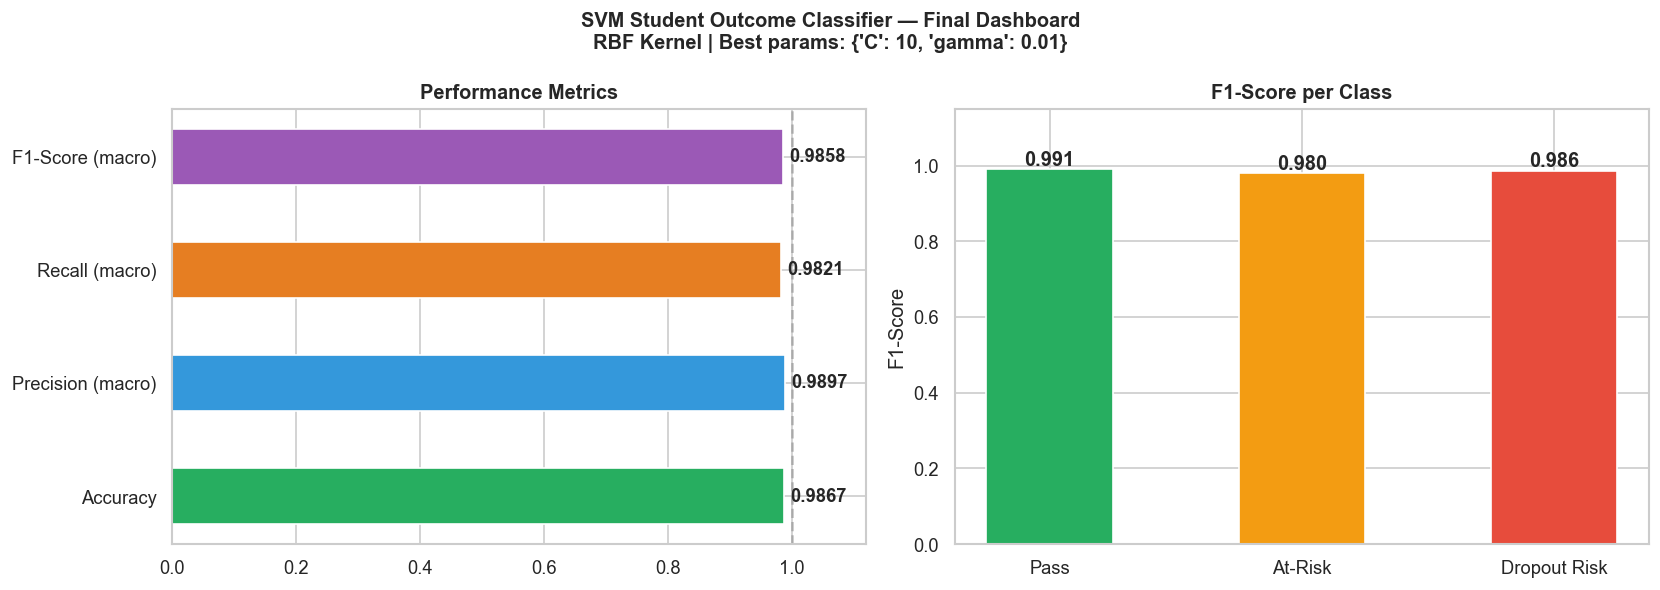


📌 KEY TAKEAWAYS
1. SVM classifies student risk effectively even with 7 features
2. C controls the bias-variance trade-off — tune it carefully
3. Feature scaling is MANDATORY before applying SVM
4. Permutation importance reveals which features matter most
5. Learning curves show how much data is "enough"
6. SVM lacks interpretability — always consider ethics in education AI
7. GridSearchCV automates optimal hyperparameter selection


In [13]:
# ============================================================
# CELL 13: Final Summary Dashboard
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'Accuracy'           : accuracy_score(y_test, y_pred),
    'Precision (macro)'  : precision_score(y_test, y_pred, average='macro', zero_division=0),
    'Recall (macro)'     : recall_score(y_test, y_pred, average='macro', zero_division=0),
    'F1-Score (macro)'   : f1_score(y_test, y_pred, average='macro', zero_division=0),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics bar chart
ax = axes[0]
palette = ['#27ae60','#3498db','#e67e22','#9b59b6']
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=palette, edgecolor='white', height=0.5)
ax.set_xlim(0, 1.12)
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=11)
ax.set_title('Performance Metrics', fontweight='bold')

# Per-class F1 scores
ax = axes[1]
per_class_f1 = f1_score(y_test, y_pred, average=None)
bars2 = ax.bar(class_names, per_class_f1, color=class_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score per Class', fontweight='bold')

plt.suptitle('SVM Student Outcome Classifier — Final Dashboard\n'
             f'RBF Kernel | Best params: {grid.best_params_}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('📌 KEY TAKEAWAYS')
print('='*60)
print('1. SVM classifies student risk effectively even with 7 features')
print('2. C controls the bias-variance trade-off — tune it carefully')
print('3. Feature scaling is MANDATORY before applying SVM')
print('4. Permutation importance reveals which features matter most')
print('5. Learning curves show how much data is "enough"')
print('6. SVM lacks interpretability — always consider ethics in education AI')
print('7. GridSearchCV automates optimal hyperparameter selection')